# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

This data represents 17 marketing campaigns between May 2008 and Nov 2010

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv('/content/sample_data/bank-additional-full.csv', sep = ';')

In [40]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [41]:
# Seeing if the data has any NULL values
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business Objective

The business objective is to develop a predictive model that identifies potential customers most likely to subscribe to a bank term deposit.

The goal is to target customers with a higher likelyhood to subscribe.

In [42]:
#Next two cells is to gain more understanding on the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [43]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [44]:
#drop duration column based on the suggestion
df = df.drop('duration', axis =1)

In [45]:
#Transform yes/no variable to 1&0
df['y'] = df['y'].map({'yes': 1, 'no': 0})
print(df['y'].value_counts())
print(df['y'].unique())

y
0    36548
1     4640
Name: count, dtype: int64
[0 1]


<Figure size 1200x1000 with 0 Axes>

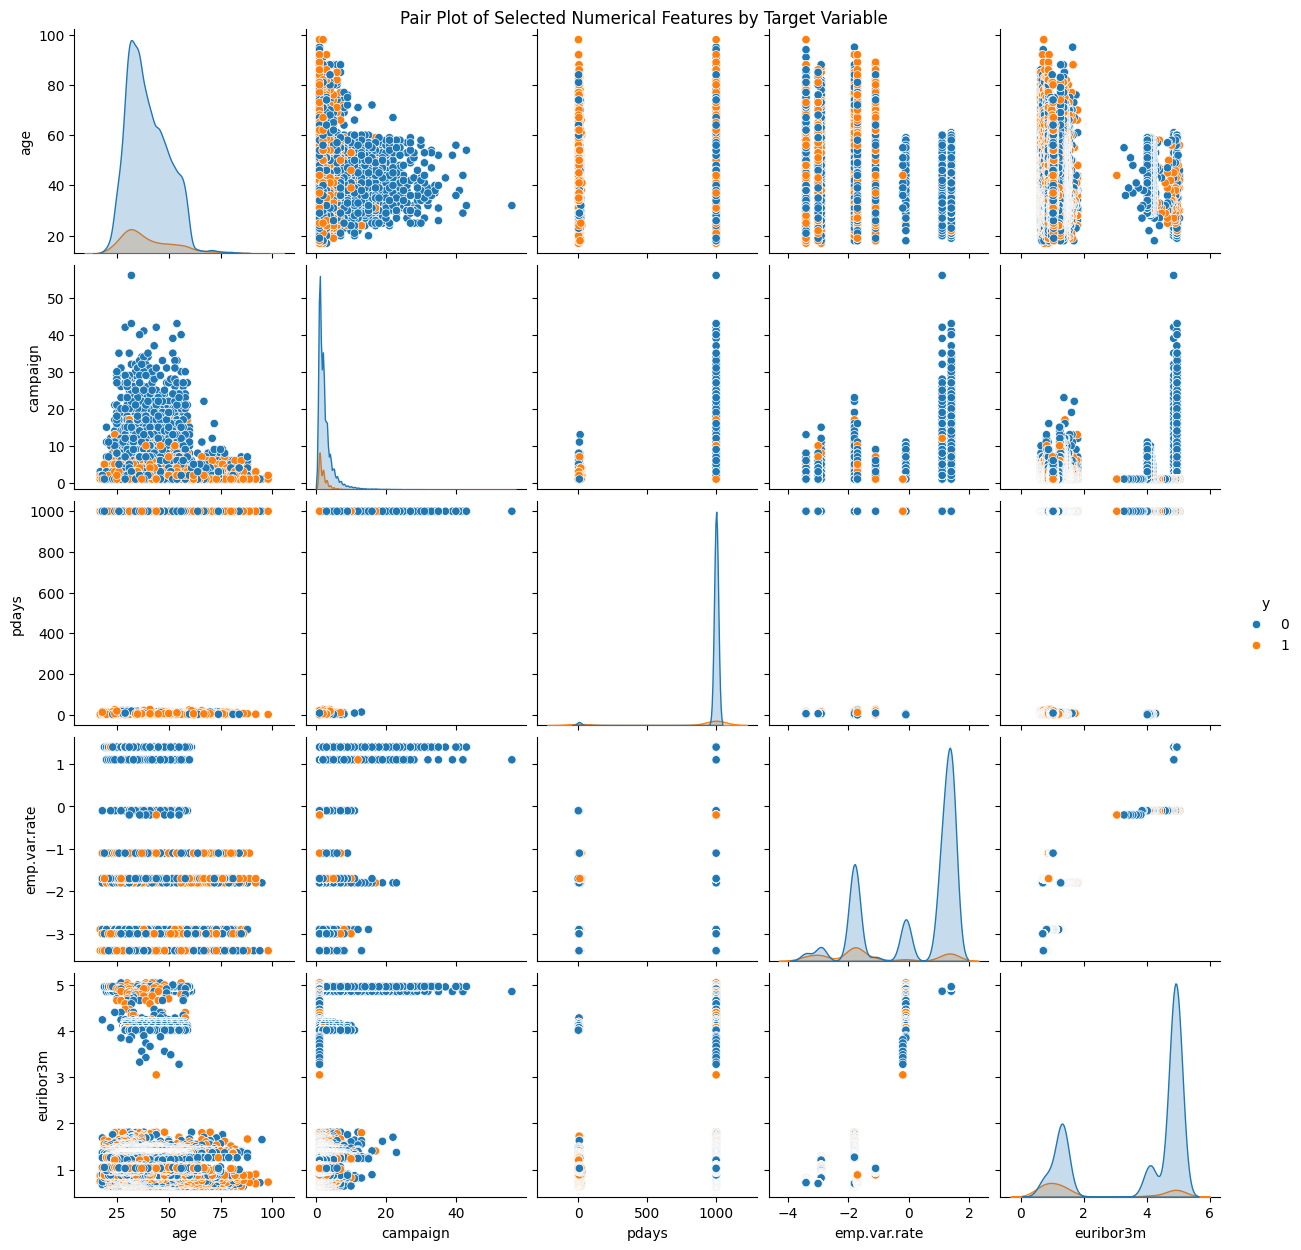

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df_num_col = ['age', 'campaign', 'pdays', 'emp.var.rate', 'euribor3m', 'y']

plt.figure(figsize=(12, 10))
sns.pairplot(df[df_num_col], hue='y')
plt.suptitle('Pair Plot of Selected Numerical Features by Target Variable',y=1)
plt.show()

The pairplot provides a summary of various variables within the dataset. Y is subscribed with color orange and blue is not with color blue. emp.var.rate and euribor3m show strong positive corelation. Age is interesting as there is a difference between younger and older subscribers. More campaign does not always lead to a positive outcome

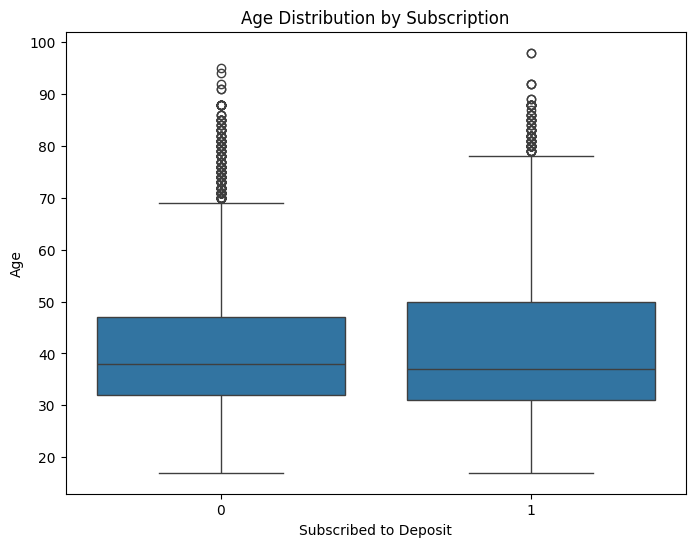

In [47]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='age', data=df)
plt.title('Age Distribution by Subscription')
plt.xlabel('Subscribed to Deposit')
plt.ylabel('Age')
plt.show()
# Boxplot clearly shows that there is a slight edge of older customers accepting
#the offer

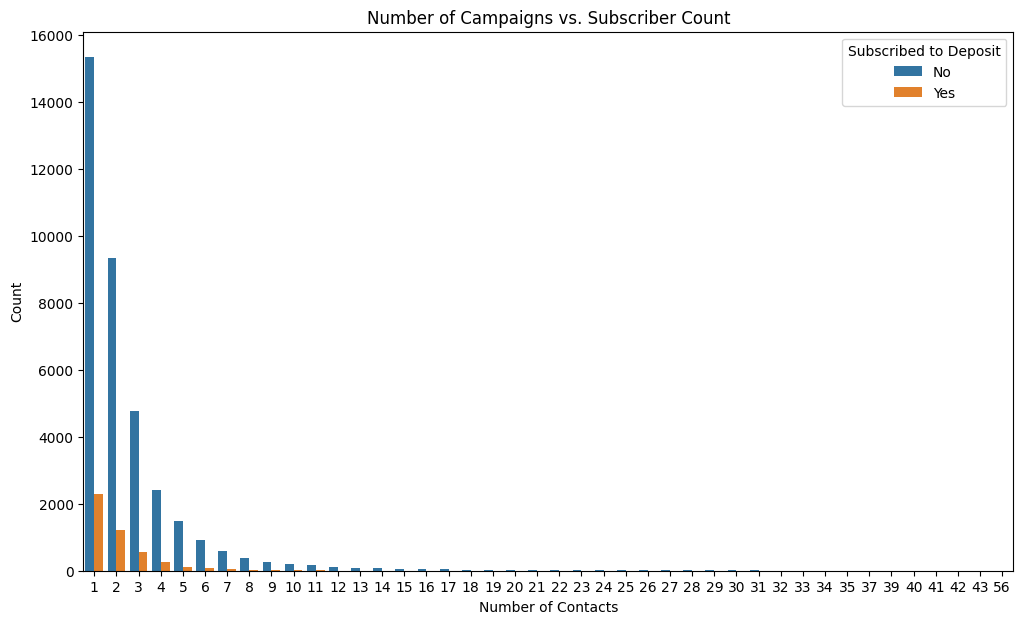

In [48]:
#chart showing number of campaign vs subscriber count
plt.figure(figsize=(12, 7))
sns.countplot(x='campaign', hue='y', data=df)
plt.title('Number of Campaigns vs. Subscriber Count')
plt.xlabel('Number of Contacts')
plt.ylabel('Count')
plt.legend(title='Subscribed to Deposit', labels=['No', 'Yes'])
plt.show()

Higher number of contacts during the campaign does not necessarily lead to positive subscription outcome as seen in the chart above

In [49]:
#Apply one hot encoding
df = pd.get_dummies(df, columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'],drop_first=True)
print("shape of Data after one-hot encoding:", df.shape)
##print(df.columns)
print(df.head())

shape of Data after one-hot encoding: (41188, 53)
   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56         1    999         0           1.1          93.994   
1   57         1    999         0           1.1          93.994   
2   37         1    999         0           1.1          93.994   
3   40         1    999         0           1.1          93.994   
4   56         1    999         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  y  ...  month_may  month_nov  \
0          -36.4      4.857       5191.0  0  ...       True      False   
1          -36.4      4.857       5191.0  0  ...       True      False   
2          -36.4      4.857       5191.0  0  ...       True      False   
3          -36.4      4.857       5191.0  0  ...       True      False   
4          -36.4      4.857       5191.0  0  ...       True      False   

   month_oct  month_sep  day_of_week_mon  day_of_week_thu  day_of_week_tue  \
0      False      False 

In [50]:
from sklearn.preprocessing import StandardScaler

# Scaling the original numeric columns
numerical_columns = [
    'age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
    'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
print("Scaled Numerical Columns")
print(df.head())

Scaled Numerical Columns
        age  campaign     pdays  previous  emp.var.rate  cons.price.idx  \
0  1.533034 -0.565922  0.195414 -0.349494      0.648092        0.722722   
1  1.628993 -0.565922  0.195414 -0.349494      0.648092        0.722722   
2 -0.290186 -0.565922  0.195414 -0.349494      0.648092        0.722722   
3 -0.002309 -0.565922  0.195414 -0.349494      0.648092        0.722722   
4  1.533034 -0.565922  0.195414 -0.349494      0.648092        0.722722   

   cons.conf.idx  euribor3m  nr.employed  y  ...  month_may  month_nov  \
0       0.886447    0.71246      0.33168  0  ...       True      False   
1       0.886447    0.71246      0.33168  0  ...       True      False   
2       0.886447    0.71246      0.33168  0  ...       True      False   
3       0.886447    0.71246      0.33168  0  ...       True      False   
4       0.886447    0.71246      0.33168  0  ...       True      False   

   month_oct  month_sep  day_of_week_mon  day_of_week_thu  day_of_week_tue  \
0

### Feature Engineering

df data set has been encoded. The duration column was dropped as per suggestion, yes/no have been converted to binary values 1&0 and all the categorial features have been one-hot encoded using get_dummies. The original integer columns have been scaled and data is prepared for the problem

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [51]:
# split the data into test and train
from sklearn.model_selection import train_test_split

#prepare the data in X&y for train and test dataset
X = df.drop('y', axis = 1)
y = df['y']
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (41188, 52)
Y Shape: (41188,)


In [52]:
#Split the data into test and train cohorts;
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (32950, 52)
X_test Shape: (8238, 52)
y_train Shape: (32950,)
y_test Shape: (8238,)


The data has now been split into Train and Test datasets as seen in the above shapes


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Based on the simple Logistic Regression Model, we see a baseline for accuracy. Other classifiers should aim to beat the accuracy which can be considered baseline

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [53]:
#Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

df_log = LogisticRegression()
df_log.fit(X_train, y_train)

LogisticRegression()

### Problem 9: Score the Model

What is the accuracy of your model?

In [54]:
import time
start_time = time.time()
df_log_pred = df_log.predict(X_test)
log_acc_test = accuracy_score(y_test, df_log_pred)
log_acc_train = accuracy_score(y_train, df_log.predict(X_train))
log_precision = precision_score(y_test, df_log_pred)
log_f1 = f1_score(y_test, df_log_pred)
end_time = time.time()
log_train_time = end_time - start_time

print(f"Logistic Regression Model")
print(f"Train Time of Logistic Model: {log_train_time:.1f} seconds")
print(f"Test Accuracy Score of Logistic Model: {log_acc_test:.2f}")
print(f"Train Accuracy Score of Logistic Model: {log_acc_train:.2f}")
print(f"Precision Score of Logistic Model: {log_precision:.2f}")
print(f"F1 Score of Logistic Model: {log_f1:.2f}")

Logistic Regression Model
Train Time of Logistic Model: 0.0 seconds
Test Accuracy Score of Logistic Model: 0.90
Train Accuracy Score of Logistic Model: 0.90
Precision Score of Logistic Model: 0.64
F1 Score of Logistic Model: 0.32


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [55]:
#KNN Model
from sklearn.neighbors import KNeighborsClassifier


start_time = time.time()
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc_test = accuracy_score(y_test, knn_pred)
knn_pred_train = knn.predict(X_train)
knn_acc_train = accuracy_score(y_train, knn_pred_train)
knn_precision = precision_score(y_test, knn_pred)
knnn_f1 = f1_score(y_test, knn_pred)
end_time = time.time()
knn_train_time = end_time - start_time

print(f"KNN Model")
print(f"Train Time of KNN Model: {knn_train_time:.1f} seconds")
print(f"Train Accuracy Score of KNN Model: {knn_acc_train:.2f}")
print(f"Test Accuracy Score of KNN Model: {knn_acc_test:.2f}")
print(f"Precision Score of KNN Model: {knn_precision:.2f}")
print(f"F1 Score of KNN Model: {knnn_f1:.2f}")

KNN Model
Train Time of KNN Model: 7.8 seconds
Train Accuracy Score of KNN Model: 0.91
Test Accuracy Score of KNN Model: 0.89
Precision Score of KNN Model: 0.55
F1 Score of KNN Model: 0.39


In [56]:
#Decision Tree Model
from sklearn.tree import DecisionTreeClassifier


start_time = time.time()
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred_test = dt.predict(X_test)
dt_acc_test = accuracy_score(y_test, dt_pred_test)
dt_pred_train = dt.predict(X_train)
dt_acc_train = accuracy_score(y_train, dt_pred_train)
dt_precision = precision_score(y_test, dt_pred_test)
dt_f1 = f1_score(y_test, dt_pred_test)
end_time = time.time()
dt_train_time = end_time - start_time

print(f"Decision Tree Model")
print(f"Train Time of Decision Tree Model: {dt_train_time:.1f} seconds")
print(f"Train Accuracy Score of Decision Tree Model: {dt_acc_train:.2f}")
print(f"Test Accuracy Score of Decision Tree Model: {dt_acc_test:.2f}")
print(f"Precision Score of Decision Tree Model: {dt_precision:.2f}")
print(f"F1 Score of Decision Tree Model: {dt_f1:.2f}")

Decision Tree Model
Train Time of Decision Tree Model: 0.3 seconds
Train Accuracy Score of Decision Tree Model: 1.00
Test Accuracy Score of Decision Tree Model: 0.84
Precision Score of Decision Tree Model: 0.30
F1 Score of Decision Tree Model: 0.32


In [57]:
#SVM Model
from sklearn.svm import SVC


start_time = time.time()
svm = SVC()
svm.fit(X_train, y_train)
svm_pred_test = svm.predict(X_test)
svm_acc_test = accuracy_score(y_test, svm_pred_test)
svm_pred_train = svm.predict(X_train)
svm_acc_train = accuracy_score(y_train, svm_pred_train)
svm_precision = precision_score(y_test, svm_pred_test)
svm_f1 = f1_score(y_test, svm_pred_test)
end_time = time.time()
svm_train_time = end_time - start_time

print(f"SVM Model")
print(f"Train Time of SVM Model: {svm_train_time:.1f} seconds")
print(f"Train Accuracy Score of SVM Model: {svm_acc_train:.2f}")
print(f"Test Accuracy Score of SVM Model: {svm_acc_test:.2f}")
print(f"Precision Score of SVM Model: {svm_precision:.2f}")
print(f"F1 Score of SVM Model: {svm_f1:.2f}")

SVM Model
Train Time of SVM Model: 138.7 seconds
Train Accuracy Score of SVM Model: 0.91
Test Accuracy Score of SVM Model: 0.90
Precision Score of SVM Model: 0.62
F1 Score of SVM Model: 0.35


In [58]:

# model performance data in a tabular format specified in problem 10
all_model_data = {'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Train Time (s)': [log_train_time,knn_train_time,dt_train_time,svm_train_time],
    'Train Accuracy': [log_acc_train,knn_acc_train,dt_acc_train,svm_acc_train],
    'Test Accuracy': [log_acc_test,knn_acc_test,dt_acc_test,svm_acc_test],
     'f1 Score': [log_f1,knnn_f1,dt_f1,svm_f1],
     'Precision Score':[log_precision,knn_precision,dt_precision,svm_precision]}

all_mod_comp_df = pd.DataFrame(all_model_data)

display(all_mod_comp_df)

,Model,Train Time (s),Train Accuracy,Test Accuracy,f1 Score,Precision Score
0,Logistic Regression,0.046127,0.901396,0.897062,0.319422,0.639871
1,KNN,7.828351,0.914446,0.892328,0.388697,0.546512
2,Decision Tree,0.320866,0.995357,0.837461,0.318575,0.303883
3,SVM,138.693548,0.905432,0.897062,0.352672,0.616000


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [59]:
#Hyper parameter tuning for logistic regression using GridsearchCV
from sklearn.model_selection import GridSearchCV

start_time = time.time()
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_log = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_log.fit(X_train, y_train)
grid_log_model = grid_log.best_estimator_
grid_log_pred_test = grid_log_model.predict(X_test)
grid_log_acc_test = accuracy_score(y_test, grid_log_pred_test)
grid_log_pred_train = grid_log_model.predict(X_train)
grid_log_acc_train = accuracy_score(y_train, grid_log_pred_train)
grid_log_precision = precision_score(y_test, grid_log_pred_test)
grid_log_f1 = f1_score(y_test, grid_log_pred_test)
end_time = time.time()
grid_log_train_time = end_time - start_time



print(f"Tuned Logistic Regression Model Estimator: {grid_log_model}")
print(f"Train Time of Tuned Logistic Model: {grid_log_train_time:.1f} seconds")
print(f"Test Accuracy Score Tuned Logistic Model: {grid_log_acc_test:.2f}")
print(f"Train Accuracy Score Tuned Logistic Model: {grid_log_acc_train:.2f}")
print(f"Precision Score Tuned Logistic Model: {grid_log_precision:.2f}")
print(f"F1 Score Tuned Logistic Model: {grid_log_f1:.2f}")

Tuned Logistic Regression Model Estimator: LogisticRegression(C=0.01)
Train Time of Tuned Logistic Model: 15.7 seconds
Test Accuracy Score Tuned Logistic Model: 0.90
Train Accuracy Score Tuned Logistic Model: 0.90
Precision Score Tuned Logistic Model: 0.67
F1 Score Tuned Logistic Model: 0.31


In [60]:
# Hyperparameter tuning for KNN

start_time = time.time()
param_grid = {'n_neighbors': [1,3,5,7,9,11,13,15,17]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_knn.fit(X_train, y_train)
grid_knn_model = grid_knn.best_estimator_
grid_knn_pred_test = grid_knn_model.predict(X_test)
grid_knn_acc_test = accuracy_score(y_test, grid_knn_pred_test)
grid_knn_pred_train = grid_knn_model.predict(X_train)
grid_knn_acc_train = accuracy_score(y_train, grid_knn_pred_train)
grid_knn_precision = precision_score(y_test, grid_knn_pred_test)
grid_knn_f1 = f1_score(y_test, grid_knn_pred_test)
end_time = time.time()
grid_knn_train_time = end_time - start_time

print(f"Grid n KNN Model: {grid_knn_model}")
print(f"Train Time of Tuned KNN Model: {grid_knn_train_time:.1f} seconds")
print(f"Test Accuracy Score for tuned KNN Model: {grid_knn_acc_test:.2f}")
print(f"Train Accuracy Score for tuned KNN Model: {grid_knn_acc_train:.2f}")
print(f"Precision Score for tuned KNN Model: {grid_knn_precision:.2f}")
print(f"F1 Score for tuned KNN Model: {grid_knn_f1:.2f}")

Grid n KNN Model: KNeighborsClassifier(n_neighbors=17)
Train Time of Tuned KNN Model: 53.3 seconds
Test Accuracy Score for tuned KNN Model: 0.89
Train Accuracy Score for tuned KNN Model: 0.90
Precision Score for tuned KNN Model: 0.58
F1 Score for tuned KNN Model: 0.35


In [61]:
#Hyperparameter Tuning for Decision Tree

start_time = time.time()
param_grid = {'max_depth': [None,1,3,5,7,9,10,15,20,25,30,35,40,45,50]}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_dt.fit(X_train, y_train)
grid_dt_model = grid_dt.best_estimator_
grid_dt_pred_test = grid_dt_model.predict(X_test)
grid_dt_acc_test = accuracy_score(y_test, grid_dt_pred_test)
grid_dt_pred_train = grid_dt_model.predict(X_train)
grid_dt_acc_train = accuracy_score(y_train, grid_dt_pred_train)
grid_dt_precision = precision_score(y_test, grid_dt_pred_test)
grid_dt_f1 = f1_score(y_test, grid_dt_pred_test)
end_time = time.time()
grid_dt_train_time = end_time - start_time

print(f"Max Depth Decision Tree Model:{grid_dt_model}")
print(f"Train Time of Tuned Decision Tree Model: {grid_dt_train_time:.1f} seconds")
print(f"Test Accuracy Score of Tuned Decision Tree Model: {grid_dt_acc_test:.2f}")
print(f"Train Accuracy Score of Tuned Decision Tree Model: {grid_dt_acc_train:.2f}")
print(f"Precision Score of Tuned Decision Tree Model: {grid_dt_precision:.2f}")
print(f"F1 Score of Tuned Decision Tree Model: {grid_dt_f1:.2f}")

Max Depth Decision Tree Model:DecisionTreeClassifier(max_depth=5)
Train Time of Tuned Decision Tree Model: 12.3 seconds
Test Accuracy Score of Tuned Decision Tree Model: 0.90
Train Accuracy Score of Tuned Decision Tree Model: 0.90
Precision Score of Tuned Decision Tree Model: 0.61
F1 Score of Tuned Decision Tree Model: 0.34


In [62]:
#Hyperparameter tuning of SVM (Timing out)
#from sklearn.model_selection import GridSearchCV

#start_time = time.time()
#param_grid = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1,1]}
#grid_svm = GridSearchCV(SVC(), param_grid, cv=5)
#grid_svm.fit(X_train, y_train)
#grid_svm_model = grid_svm.best_estimator_
#grid_svm_pred_test = grid_svm_model.predict(X_test)
#grid_svm_acc_test = accuracy_score(y_test, grid_svm_pred_test)
#grid_svm_pred_train = grid_svm_model.predict(X_train)
#grid_svm_acc_train = accuracy_score(y_train, grid_svm_pred_train)
#end_time = time.time()
#grid_svm_train_time = end_time - start_time

#print(f"Estimator SVM Model:{grid_svm_model}")
#print(f"Train Time of Tuned SVM Model: {grid_svm_train_time:.1f} seconds")
#print(f"Test Accuracy Score of Tuned SVM Model: {grid_svm_acc_test:.2f}")
#print(f"Train Accuracy Score of Tuned SVM Model: {grid_svm_acc_train:.2f}")

In [63]:
# model performance data in a tabular format specified in problem 10
all_model_tuned_data = {'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'
,'Logitic Regression Tuned','KNN_Tuned','Decision Tree Tuned','SVM Tuned'],
    'Train Time (s)': [log_train_time,knn_train_time,dt_train_time,svm_train_time,
                       grid_log_train_time,grid_knn_train_time,grid_dt_train_time,
                       'Timed out'],
    'Train Accuracy': [log_acc_train,knn_acc_train,dt_acc_train,svm_acc_train,
                       grid_log_acc_test,grid_knn_acc_test,grid_dt_acc_test,
                       'Timed out'],
    'Test Accuracy': [log_acc_test,knn_acc_test,dt_acc_test,svm_acc_test,
                      grid_log_acc_train,grid_knn_acc_train,grid_dt_acc_train,
                      'Timed out'],
     'f1 Score': [log_f1,knnn_f1,dt_f1,svm_f1,grid_log_f1,grid_knn_f1,grid_dt_f1,'Nan'],
     'Precision Score':[log_precision,knn_precision,dt_precision,svm_precision,grid_log_precision,
                        grid_knn_precision,grid_dt_precision,'Nan'],
                        }

all_mod_tuned_comp_df = pd.DataFrame(all_model_tuned_data)

display(all_mod_tuned_comp_df)

,Model,Train Time (s),Train Accuracy,Test Accuracy,f1 Score,Precision Score
0,Logistic Regression,0.046127,0.901396,0.897062,0.319422,0.639871
1,KNN,7.828351,0.914446,0.892328,0.388697,0.546512
2,Decision Tree,0.320866,0.995357,0.837461,0.318575,0.303883
3,SVM,138.693548,0.905432,0.897062,0.352672,0.616
4,Logitic Regression Tuned,15.664535,0.897912,0.901457,0.306678,0.669065
5,KNN_Tuned,53.331231,0.894028,0.904643,0.349963,0.57598
6,Decision Tree Tuned,12.298281,0.896213,0.904492,0.337723,0.61236
7,SVM Tuned,Timed out,Timed out,Timed out,Nan,Nan


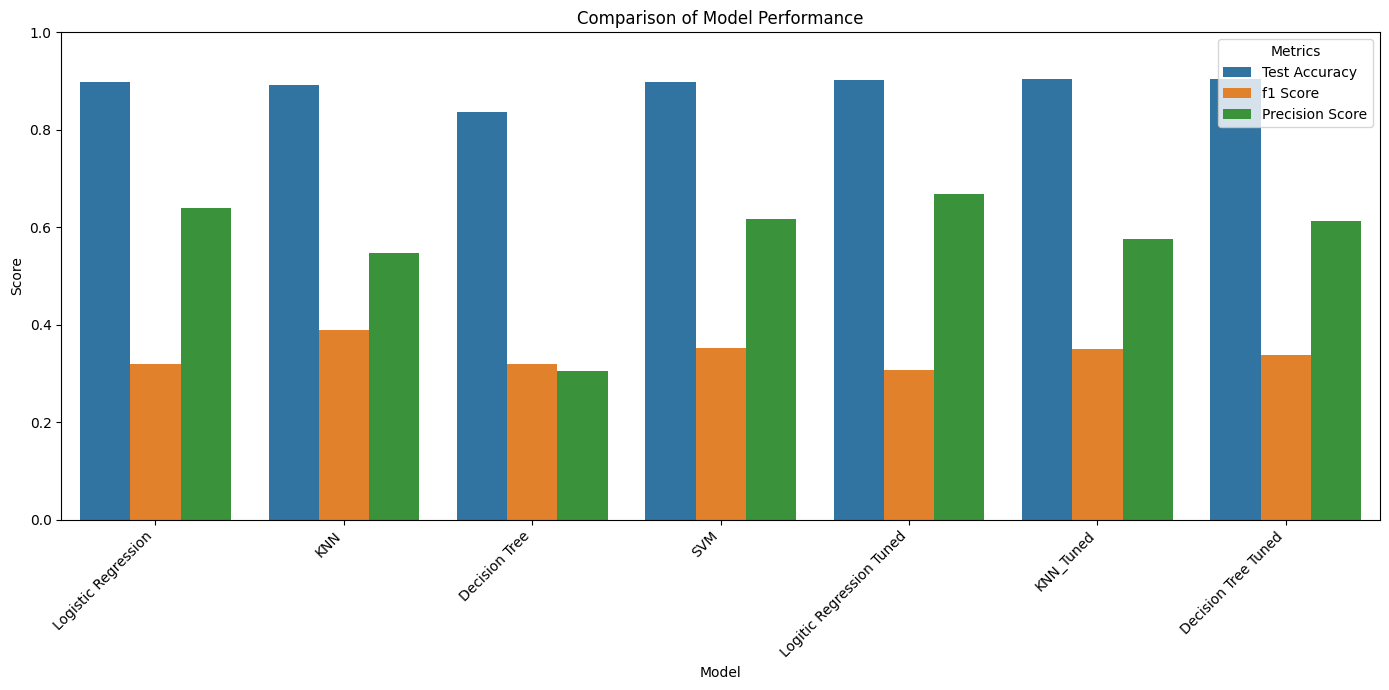

In [64]:
#Chart comparison
pl_df = all_mod_tuned_comp_df[all_mod_tuned_comp_df['Train Time (s)'] != 'Timed out'].copy()
pl_df[['Train Time (s)', 'Train Accuracy', 'Test Accuracy', 'f1 Score', 'Precision Score']] = \
pl_df[['Train Time (s)', 'Train Accuracy', 'Test Accuracy', 'f1 Score', 'Precision Score']].astype(float)

mel_df = pl_df.melt(id_vars=['Model'], value_vars=['Test Accuracy', 'f1 Score', 'Precision Score'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=mel_df)
plt.title('Comparison of Model Performance')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

### Best Performing Model (based on the data)

Tuned Logistic Regression model achieved highest precision score of 0.669 and a good test accuracy score of 0.901 making it ideal model for customers to subscribe

Tuned Decision Tree also is a close contender with a test accuracy of 0.904 and Precision of 0.612 with a very low training time.

Considering all parameters, Tuned Logistic Regression has slight edge over the tuned decision tree model

In [65]:
#Exploring the top coefficients in Logistic Regression
coeff = df_log.coef_[0]
feature_col = X_train.columns
feature_names = list(feature_col)
coefficients = coeff.tolist()
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 5 Coefficients in Logistic Regression:")
display(coef_df.head(5))

Top 5 Coefficients in Logistic Regression:


,Feature,Coefficient,Abs_Coefficient
4,emp.var.rate,-2.232100,2.232100
41,month_mar,1.438901,1.438901
5,cons.price.idx,1.140211,1.140211
36,contact_telephone,-0.773096,0.773096
51,poutcome_success,0.647133,0.647133


### Data Analysis Results

1.The Logistic Regression model identified the Employment Variation Rate (emp.var.rate), the month of March (month_mar), the Consumer Price Index (con.price.idx), and telephone contact as its top coefficients.

2.A low F1 score for the minority class indicates a significant challenge in accurately predicting positive cases.

3.Initial data exploration suggests that older customers have a higher probability of subscribing, whereas excessive campaign contacts do not necessarily yield better outcomes.

4.The Employment Variation Rate (emp.var.rate) and the 3-month Euribor rate (euribor3m) have a strong positive correlation with each other, but both are

## Insights or Next Steps

###Refine Marketing Strategy:

Target older customer cohorts and optimize campaign frequency, avoiding too much contacts. Campaigns could also be timed based on macro-economic indicators like employment variation rate and consumer price index, which were identified as highly influential features.

###Enhance Model Performance for Minority Class:

The data can be further analyzed to address the minority class, which may improve the model's ability to identify potential subscribers.

##### Questions